In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time, copy, warnings

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device aktif: {device}")

weights = models.ResNet18_Weights.IMAGENET1K_V1
eval_transforms = weights.transforms()
train_transforms_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
])

print("Memuat dataset Oxford-IIIT Pet...")
dataset_trainval = datasets.OxfordIIITPet(root='./data', split='trainval', download=True)
dataset_test = datasets.OxfordIIITPet(root='./data', split='test', download=True)

gabungan_dataset = torch.utils.data.ConcatDataset([dataset_trainval, dataset_test])
all_classes = dataset_trainval.classes

target_classes_lower = [
    'abyssinian', 'bengal', 'birman', 'bombay', 'british_shorthair',
    'beagle', 'boxer', 'chihuahua', 'pug', 'yorkshire_terrier'
]

selected_class_idx = [idx for idx, name in enumerate(all_classes) if name.lower() in target_classes_lower]

all_labels = dataset_trainval._labels + dataset_test._labels
valid_indices = [i for i, label in enumerate(all_labels) if label in selected_class_idx]
valid_labels = [all_labels[i] for i in valid_indices]

label_map = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_class_idx)}
mapped_labels = [label_map[label] for label in valid_labels]

idx_train, idx_temp, y_train, y_temp = train_test_split(
    valid_indices, mapped_labels, test_size=0.30, stratify=mapped_labels, random_state=42
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

class FilteredPetDataset(Dataset):
    def __init__(self, original_dataset, indices, label_map, transform=None):
        self.original_dataset = original_dataset
        self.indices = indices
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img, label = self.original_dataset[real_idx]
        if img.mode != 'RGB':
            img = img.convert('RGB')
        new_label = self.label_map[label]
        if self.transform:
            img = self.transform(img)
        return img, new_label

train_dataset = FilteredPetDataset(gabungan_dataset, idx_train, label_map, transform=eval_transforms)
train_dataset_aug = FilteredPetDataset(gabungan_dataset, idx_train, label_map, transform=train_transforms_aug)
val_dataset = FilteredPetDataset(gabungan_dataset, idx_val, label_map, transform=eval_transforms)
test_dataset = FilteredPetDataset(gabungan_dataset, idx_test, label_map, transform=eval_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Device aktif: cuda
Memuat dataset Oxford-IIIT Pet...


100%|██████████| 792M/792M [1:04:43<00:00, 204kB/s]
100%|██████████| 19.2M/19.2M [01:43<00:00, 186kB/s]


In [2]:
hasil_eksperimen = []

def train_model(model, criterion, optimizer, loader_train, num_epochs=25, patience=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = loader_train
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val':
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_acc = epoch_acc
                    best_epoch = epoch + 1
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stopping terpanggil setelah {epoch+1} epoch.')
            break
        print()

    time_elapsed = time.time() - since
    print(f'Training selesai dalam {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Val Acc Terbaik: {best_acc:.4f} pada epoch {best_epoch}')

    model.load_state_dict(best_model_wts)
    return model, history, time_elapsed, best_epoch

def evaluate_model(model):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return f1_score(all_labels, all_preds, average='macro')


B1
Epoch 1/30
----------
Train Loss: 2.0060 Acc: 0.2975
Val Loss: 1.9216 Acc: 0.2869

Epoch 2/30
----------
Train Loss: 1.6267 Acc: 0.3834
Val Loss: 1.9303 Acc: 0.3629

Epoch 3/30
----------
Train Loss: 1.5026 Acc: 0.4629
Val Loss: 1.7101 Acc: 0.4135

Epoch 4/30
----------
Train Loss: 1.4357 Acc: 0.4955
Val Loss: 3.9868 Acc: 0.2827

Epoch 5/30
----------
Train Loss: 1.3139 Acc: 0.5190
Val Loss: 1.5916 Acc: 0.4937

Epoch 6/30
----------
Train Loss: 1.1771 Acc: 0.5877
Val Loss: 1.4157 Acc: 0.4388

Epoch 7/30
----------
Train Loss: 1.0957 Acc: 0.6085
Val Loss: 1.9015 Acc: 0.4051

Epoch 8/30
----------
Train Loss: 0.9912 Acc: 0.6474
Val Loss: 2.7788 Acc: 0.4093

Epoch 9/30
----------
Train Loss: 0.8711 Acc: 0.7052
Val Loss: 2.1286 Acc: 0.4051

Epoch 10/30
----------
Train Loss: 0.7801 Acc: 0.7224
Val Loss: 1.8384 Acc: 0.4473

Epoch 11/30
----------
Train Loss: 0.6697 Acc: 0.7722
Val Loss: 2.5186 Acc: 0.3840
Early stopping terpanggil setelah 11 epoch.
Training selesai dalam 1m 59s
Val Acc 

100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


Epoch 1/30
----------
Train Loss: 1.2943 Acc: 0.6528
Val Loss: 0.5730 Acc: 0.9114

Epoch 2/30
----------
Train Loss: 0.4584 Acc: 0.9313
Val Loss: 0.3137 Acc: 0.9367

Epoch 3/30
----------
Train Loss: 0.2901 Acc: 0.9530
Val Loss: 0.2363 Acc: 0.9409

Epoch 4/30
----------
Train Loss: 0.2130 Acc: 0.9647
Val Loss: 0.1981 Acc: 0.9451

Epoch 5/30
----------
Train Loss: 0.1736 Acc: 0.9665
Val Loss: 0.1941 Acc: 0.9409

Epoch 6/30
----------
Train Loss: 0.1554 Acc: 0.9720
Val Loss: 0.1604 Acc: 0.9451

Epoch 7/30
----------
Train Loss: 0.1340 Acc: 0.9837
Val Loss: 0.1498 Acc: 0.9451

Epoch 8/30
----------
Train Loss: 0.1200 Acc: 0.9810
Val Loss: 0.1496 Acc: 0.9494

Epoch 9/30
----------
Train Loss: 0.0976 Acc: 0.9864
Val Loss: 0.1360 Acc: 0.9578

Epoch 10/30
----------
Train Loss: 0.0975 Acc: 0.9810
Val Loss: 0.1266 Acc: 0.9662

Epoch 11/30
----------
Train Loss: 0.0933 Acc: 0.9873
Val Loss: 0.1245 Acc: 0.9662

Epoch 12/30
----------
Train Loss: 0.0688 Acc: 0.9892
Val Loss: 0.1174 Acc: 0.9578

E

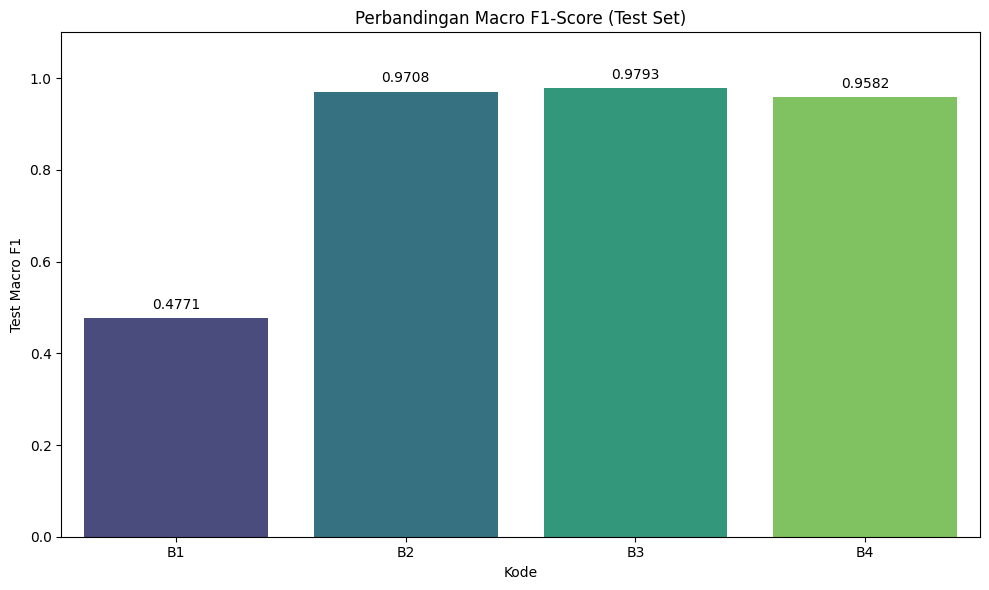

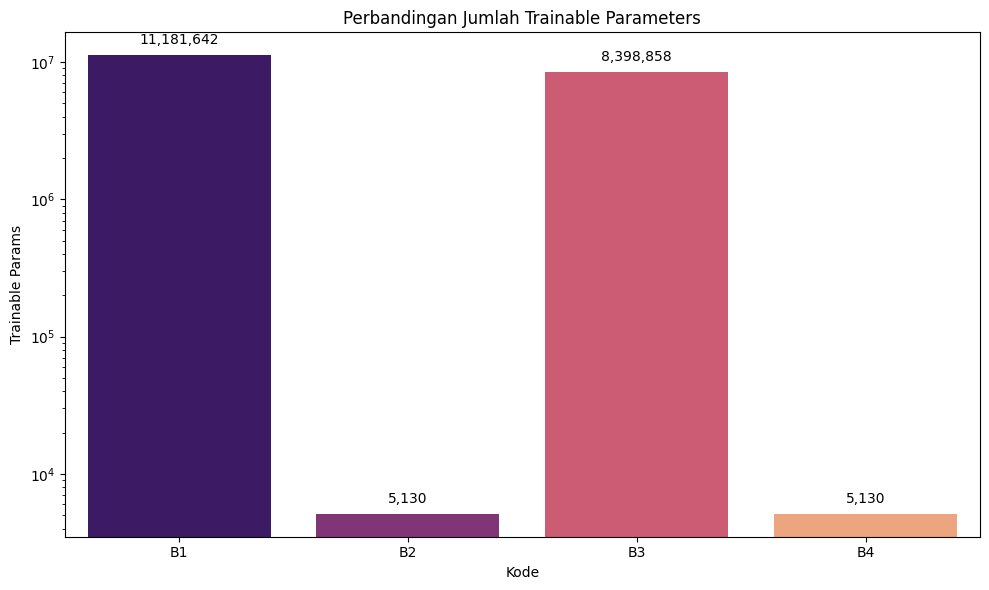

In [3]:
#B1: Baseline from Scratch
print("\n" + "="*50 + "\nB1\n" + "="*50)
model_b1 = models.resnet18(weights=None)
model_b1.fc = nn.Linear(model_b1.fc.in_features, 10)
model_b1 = model_b1.to(device)
trainable_b1 = sum(p.numel() for p in model_b1.parameters() if p.requires_grad)

optimizer_b1 = optim.AdamW(model_b1.parameters(), lr=1e-3)
model_b1, hist_b1, time_b1, ep_b1 = train_model(model_b1, nn.CrossEntropyLoss(), optimizer_b1, train_loader, 30, 5)
f1_b1 = evaluate_model(model_b1)

hasil_eksperimen.append({'Kode': 'B1', 'Kondisi': 'Baseline', 'Trainable Params': trainable_b1, 'Learning Rate': '1e-3', 'Epoch Konvergen': ep_b1, 'Waktu (detik)': round(time_b1, 2), 'Val Accuracy': round(hist_b1['val_acc'][ep_b1-1], 4), 'Test Macro F1': round(f1_b1, 4)})

#B2: Feature Extraction
print("\n" + "="*50 + "\nB2\n" + "="*50)
model_b2 = models.resnet18(weights=weights)
for param in model_b2.parameters(): param.requires_grad = False
model_b2.fc = nn.Linear(model_b2.fc.in_features, 10)
model_b2 = model_b2.to(device)
trainable_b2 = sum(p.numel() for p in model_b2.parameters() if p.requires_grad)

optimizer_b2 = optim.AdamW(model_b2.fc.parameters(), lr=1e-3)
model_b2, hist_b2, time_b2, ep_b2 = train_model(model_b2, nn.CrossEntropyLoss(), optimizer_b2, train_loader, 30, 5)
f1_b2 = evaluate_model(model_b2)

hasil_eksperimen.append({'Kode': 'B2', 'Kondisi': 'Feature Extraction', 'Trainable Params': trainable_b2, 'Learning Rate': '1e-3', 'Epoch Konvergen': ep_b2, 'Waktu (detik)': round(time_b2, 2), 'Val Accuracy': round(hist_b2['val_acc'][ep_b2-1], 4), 'Test Macro F1': round(f1_b2, 4)})

#B3: Progressive Fine-Tuning
print("\n" + "="*50 + "\nB3\n" + "="*50)
model_b3 = models.resnet18(weights=weights)
model_b3.fc = nn.Linear(model_b3.fc.in_features, 10)
for name, param in model_b3.named_parameters():
    if "layer4" in name or "fc" in name: param.requires_grad = True
    else: param.requires_grad = False
model_b3 = model_b3.to(device)
trainable_b3 = sum(p.numel() for p in model_b3.parameters() if p.requires_grad)

optimizer_b3 = optim.AdamW([{"params": model_b3.layer4.parameters(), "lr": 1e-4}, {"params": model_b3.fc.parameters(), "lr": 1e-3}])
model_b3, hist_b3, time_b3, ep_b3 = train_model(model_b3, nn.CrossEntropyLoss(), optimizer_b3, train_loader, 30, 5)
f1_b3 = evaluate_model(model_b3)

hasil_eksperimen.append({'Kode': 'B3', 'Kondisi': 'Progressive Fine-Tuning', 'Trainable Params': trainable_b3, 'Learning Rate': '1e-4 & 1e-3', 'Epoch Konvergen': ep_b3, 'Waktu (detik)': round(time_b3, 2), 'Val Accuracy': round(hist_b3['val_acc'][ep_b3-1], 4), 'Test Macro F1': round(f1_b3, 4)})

#B4: Data Augmentation
print("\n" + "="*50 + "\nB4\n" + "="*50)
model_b4 = models.resnet18(weights=weights)
for param in model_b4.parameters(): param.requires_grad = False
model_b4.fc = nn.Linear(model_b4.fc.in_features, 10)
model_b4 = model_b4.to(device)
trainable_b4 = sum(p.numel() for p in model_b4.parameters() if p.requires_grad)

optimizer_b4 = optim.AdamW(model_b4.fc.parameters(), lr=1e-3)
model_b4, hist_b4, time_b4, ep_b4 = train_model(model_b4, nn.CrossEntropyLoss(), optimizer_b4, train_loader_aug, 30, 5)
f1_b4 = evaluate_model(model_b4)

hasil_eksperimen.append({'Kode': 'B4', 'Kondisi': 'Uji Augmentation (FE)', 'Trainable Params': trainable_b4, 'Learning Rate': '1e-3', 'Epoch Konvergen': ep_b4, 'Waktu (detik)': round(time_b4, 2), 'Val Accuracy': round(hist_b4['val_acc'][ep_b4-1], 4), 'Test Macro F1': round(f1_b4, 4)})

#Visualisasi & Ekspor
df = pd.DataFrame(hasil_eksperimen)
df.to_csv('laporan_lengkap_final.csv', index=False)
print("\n" + "="*50 + "\nSemua proses selesai! Menyimpan grafik...\n" + "="*50)
print(df.to_string())

plt.figure(figsize=(10, 6))
sns.barplot(x='Kode', y='Test Macro F1', data=df, palette='viridis')
plt.title('Perbandingan Macro F1-Score (Test Set)')
plt.ylim(0, 1.1)
for index, value in enumerate(df['Test Macro F1']):
    plt.text(index, value + 0.02, str(round(value, 4)), ha='center')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Kode', y='Trainable Params', data=df, palette='magma')
plt.title('Perbandingan Jumlah Trainable Parameters')
plt.yscale('log')
for index, value in enumerate(df['Trainable Params']):
    plt.text(index, value * 1.2, f"{value:,}", ha='center')
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import torchvision

#C1: Visualisasi Kurva Loss B1, B2, B3
plt.figure(figsize=(15, 5))
for i, (name, hist) in enumerate([('B1 (Scratch)', hist_b1), ('B2 (FE)', hist_b2), ('B3 (Fine-Tuning)', hist_b3)]):
    plt.subplot(1, 3, i+1)
    plt.plot(hist['train_loss'], label='Train Loss', color='blue')
    plt.plot(hist['val_loss'], label='Val Loss', color='red')
    plt.title(f'Kurva Loss {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

#C3: Failure Analysis (5 Sampel Misklasifikasi Model B3)
model_b3.eval()
misclassified = []
class_names = [all_classes[idx] for idx in selected_class_idx]

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_b3(inputs)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, 1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                misclassified.append({
                    'image': inputs[i].cpu(),
                    'true': class_names[labels[i].item()],
                    'pred': class_names[preds[i].item()],
                    'conf': confs[i].item()
                })
                if len(misclassified) >= 5: break
        if len(misclassified) >= 5: break

plt.figure(figsize=(15, 6))
for i, m in enumerate(misclassified):
    ax = plt.subplot(1, 5, i+1)
    img = m['image'].numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)
    plt.imshow(img)
    plt.title(f"Asli: {m['true']}\nPred: {m['pred']}\nConf: {m['conf']:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined